<div style="
text-align:center;
background-color:#556B2F;
color:white;
padding:20px;
border-radius:10px;
font-family:Arial, sans-serif;">

<h1>🛒 ShopEase Data Analytics Project</h1>
<h3>Data Cleaning, Exploratory Data Analysis & Business Insights</h3>

</div>

<div style="
    background-color: #556B2F;
    padding: 14px 20px;
    border-radius: 8px;
    text-align: center;
">
    <h2 style="
        color: white;
        margin: 0;
        font-family: Arial, sans-serif;
        font-weight: 600;
    ">
        📂 Data Loading and Initial Overview
    </h2>
</div>

## Step 1: Import Libraries and load data set

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime

# Display and chart settings
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("shopease_raw_orders.csv")
print(df.shape)
df.head()

(10020, 16)


,OrderID,CustomerID,OrderDate,CustomerAge,Gender,City,Category,Product,Quantity,UnitPrice,Discount,PaymentMethod,OrderStatus,DeliveryDate,Rating,TotalAmount
0,18129,C0507,2026-02-01 23:39:00,68.0,Female,Alexandria,Electronics,Laptop,4,18000,0.0,Wallet,Delivered,2026-02-04 23:39:00,5.0,72000.0
1,11666,C0207,2026-03-03 10:37:00,21.0,Female,Cairo,Sports,Yoga Mat,2,600,0.1,Wallet,Delivered,2026-03-07 10:37:00,1.0,1080.0
2,12859,C1112,2026-05-23 17:57:00,23.0,Male,Aswan,Fashion,Shoes,-1,1500,10%,Bank Transfer,Delivered,2026-05-27 17:57:00,4.0,1350.0
3,19787,C1322,2026-01-29 07:51:00,23.0,Male,Tanta,Beauty,Hair Dryer,4,1300,0.1,Wallet,Delivered,2026-01-30 07:51:00,4.0,4680.0
4,16473,C0314,2026-06-23 20:17:00,62.0,Female,Tanta,Electronics,Laptop,1,18000,0.1,Mastercard,Delivered,2026-06-27 20:17:00,5.0,16200.0


## Step 2.Introduction

### Background
E-commerce businesses generate large amounts of order data every day, covering what customers buy, how they pay, where they live and whether their orders are delivered. When this data is recorded by many systems and people, it usually contains errors such as inconsistent spellings, mixed date formats, missing entries and invalid values. Raw data like this cannot be trusted for decisions until it is cleaned and examined.

### Business Context
ShopEase is an online retail business selling products in five categories: Electronics, Fashion, Home, Sports and Beauty. Orders come from six cities (Cairo, Giza, Alexandria, Mansoura, Tanta and Aswan) and are paid for by cash, Visa, Mastercard, wallet or bank transfer. Each order ends up Delivered, Pending or Cancelled. Management needs to understand sales performance, customer behavior and order fulfilment.

The dataset used in this project is a **synthetic (practice) dataset** of 10,020 order records taken from Kaggle. The findings therefore describe this dataset and not a real company.

### Problem Statement
ShopEase's raw orders data contains quality issues that make direct analysis unreliable. Without cleaning and structured exploration, the business cannot accurately measure revenue, identify its strongest products and cities, understand cancellations and delivery performance, or judge the effect of discounts.

### Aim
To clean the ShopEase raw orders dataset and carry out an end-to-end exploratory data analysis using Python, in order to identify sales trends, customer and product patterns, and order-fulfilment issues, and to convert them into business insights and recommendations.

### Objectives
1. Understand the structure and content of the dataset.
2. Detect and correct data-quality problems: missing values, duplicates, inconsistent text, mixed formats, invalid values and outliers.
3. Create useful new features, such as order month, delivery time and discount percentage.
4. Measure key performance indicators (KPIs) such as total revenue, number of orders, average order value and cancellation rate.
5. Analyze sales by time, category, product, city and payment method.
6. Examine order status, delivery time and customer ratings.
7. Apply descriptive statistics and correlation to support the findings.
8. Present the results with suitable visualizations.
9. Give practical recommendations that are supported by the analysis.

### Business Questions
1. How much revenue does ShopEase generate, and how does it change month by month?
2. Which categories and products contribute most to revenue and orders?
3. What percentage of orders is delivered, pending or cancelled, and does it differ by city, category or payment method?
4. Which cities and payment methods are used most?
5. Do discounts change the quantity ordered, and how much revenue do they give up?
6. How long does delivery take, and does it vary by city?
7. Are customer ratings related to delivery time or discount?
8. What do customer age and gender tell us about buying behavior?

## Step 3.Column description & quick inspection

In [3]:
df.columns

Index(['OrderID', 'CustomerID', 'OrderDate', 'CustomerAge', 'Gender', 'City',
       'Category', 'Product', 'Quantity', 'UnitPrice', 'Discount',
       'PaymentMethod', 'OrderStatus', 'DeliveryDate', 'Rating',
       'TotalAmount'],
      dtype='object')

In [4]:
df.info()
print("\nOriginal data types:")
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10020 entries, 0 to 10019
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   OrderID        10020 non-null  int64  
 1   CustomerID     10005 non-null  object 
 2   OrderDate      10020 non-null  object 
 3   CustomerAge    9900 non-null   float64
 4   Gender         10020 non-null  object 
 5   City           10020 non-null  object 
 6   Category       10020 non-null  object 
 7   Product        10000 non-null  object 
 8   Quantity       10020 non-null  int64  
 9   UnitPrice      10020 non-null  int64  
 10  Discount       9920 non-null   object 
 11  PaymentMethod  9970 non-null   object 
 12  OrderStatus    10020 non-null  object 
 13  DeliveryDate   7790 non-null   object 
 14  Rating         7728 non-null   float64
 15  TotalAmount    10020 non-null  float64
dtypes: float64(3), int64(3), object(10)
memory usage: 1.2+ MB

Original data types:


OrderID            int64
CustomerID        object
OrderDate         object
CustomerAge      float64
Gender            object
City              object
Category          object
Product           object
Quantity           int64
UnitPrice          int64
Discount          object
PaymentMethod     object
OrderStatus       object
DeliveryDate      object
Rating           float64
TotalAmount      float64
dtype: object

In [5]:
df.describe()

,OrderID,CustomerAge,Quantity,UnitPrice,Rating,TotalAmount
count,10020.000000,9900.000000,10020.000000,10020.000000,7728.000000,10020.000000
mean,14999.295908,44.381212,1.947605,1956.412176,3.958851,3308.779741
std,2888.444735,15.703142,1.100476,5403.755496,1.023657,7328.702149
min,10001.000000,-3.000000,-3.000000,-500.000000,-1.000000,200.000000
25%,12496.750000,31.000000,1.000000,650.000000,3.000000,855.000000
50%,14998.500000,44.000000,2.000000,900.000000,4.000000,1600.000000
75%,17501.250000,58.000000,3.000000,1500.000000,5.000000,2853.250000
max,20000.000000,150.000000,4.000000,150000.000000,6.000000,72000.000000


In [6]:
df.isnull().sum()

OrderID             0
CustomerID         15
OrderDate           0
CustomerAge       120
Gender              0
City                0
Category            0
Product            20
Quantity            0
UnitPrice           0
Discount          100
PaymentMethod      50
OrderStatus         0
DeliveryDate     2230
Rating           2292
TotalAmount         0
dtype: int64

<div style="
    background-color: #6B8E23;
    padding: 14px 20px;
    border-radius: 8px;
    text-align: center;
">
    <h2 style="
        color: white;
        margin: 0;
        font-family: Arial, sans-serif;
        font-weight: 600;
    ">
        🧹 Data Preprocessing
    </h2>
</div>

## Cleaning stage (part 1)

### text cleaning

In [7]:
text_columns = ["Gender", "City", "Category", "Product", "PaymentMethod", "OrderStatus"]

for col in text_columns:
    df[col] = df[col].str.strip()

for col in ["City", "Category", "Product", "PaymentMethod"]:
    df[col] = df[col].str.title()

df["Gender"] = df["Gender"].str.lower().map({
    "male": "Male", "m": "Male",
    "female": "Female", "f": "Female"
})

df["OrderStatus"] = (
    df["OrderStatus"].str.lower()
    .replace({"canceled": "cancelled"})
    .str.title()
)

for col in ["Gender", "City", "Category", "PaymentMethod", "OrderStatus"]:
    print(col, "->", df[col].nunique(), "unique values")

print("Gender missing:", df["Gender"].isnull().sum())
print("Unique products:", df["Product"].nunique())

Gender -> 2 unique values
City -> 6 unique values
Category -> 5 unique values
PaymentMethod -> 5 unique values
OrderStatus -> 3 unique values
Gender missing: 0
Unique products: 25


### Discount

In [8]:
def convert_discount(value):
    if pd.isnull(value):
        return np.nan
    text = str(value).strip()
    if text.endswith("%"):
        return float(text.replace("%", "")) / 100
    return float(text)

df["Discount"] = df["Discount"].apply(convert_discount)

print(df["Discount"].value_counts(dropna=False).sort_index())

Discount
0.00    3465
0.05    1940
0.10    2515
0.15    1511
0.20     489
NaN      100
Name: count, dtype: int64


### dates

In [9]:
def convert_order_date(value):
    text = str(value).strip()
    possible_formats = ["%Y-%m-%d %H:%M:%S", "%Y-%m-%d", "%d-%m-%Y", "%d/%m/%Y", "%b %d %Y"]
    for date_format in possible_formats:
        try:
            return datetime.strptime(text, date_format)
        except ValueError:
            continue
    return pd.NaT

df["OrderDate"] = df["OrderDate"].apply(convert_order_date)
df["OrderDate"] = pd.to_datetime(df["OrderDate"])
df["DeliveryDate"] = pd.to_datetime(df["DeliveryDate"])

print("Missing OrderDate:", df["OrderDate"].isnull().sum())
print("Missing DeliveryDate:", df["DeliveryDate"].isnull().sum())
print("Earliest order:", df["OrderDate"].min())
print("Latest order:", df["OrderDate"].max())

Missing OrderDate: 25
Missing DeliveryDate: 2230
Earliest order: 2026-01-01 00:00:00
Latest order: 2026-06-29 23:40:00


### missing values and invalid ages and ratings

In [10]:
df["PaymentMethod"] = df["PaymentMethod"].fillna("Unknown")
df["Product"] = df["Product"].fillna("Unknown")

df.loc[(df["CustomerAge"] < 0) | (df["CustomerAge"] > 100), "CustomerAge"] = np.nan
df["CustomerAge"] = df["CustomerAge"].fillna(df["CustomerAge"].median())

df["Discount"] = df["Discount"].fillna(0)

df.loc[(df["Rating"] < 1) | (df["Rating"] > 5), "Rating"] = np.nan

df["Delivery_Date_Missing_Flag"] = (
    (df["OrderStatus"] == "Delivered") & (df["DeliveryDate"].isnull())
)

print(df.shape)
print("Mean rating:", round(df["Rating"].mean(), 2))
print("Age median:", df["CustomerAge"].median())
print("Flagged orders:", df["Delivery_Date_Missing_Flag"].sum())

(10020, 17)
Mean rating: 3.96
Age median: 44.0
Flagged orders: 35


### final check for this stage

In [11]:
print(df.isnull().sum())
df.dtypes

OrderID                          0
CustomerID                      15
OrderDate                       25
CustomerAge                      0
Gender                           0
City                             0
Category                         0
Product                          0
Quantity                         0
UnitPrice                        0
Discount                         0
PaymentMethod                    0
OrderStatus                      0
DeliveryDate                  2230
Rating                        2307
TotalAmount                      0
Delivery_Date_Missing_Flag       0
dtype: int64


OrderID                                int64
CustomerID                            object
OrderDate                     datetime64[ns]
CustomerAge                          float64
Gender                                object
City                                  object
Category                              object
Product                               object
Quantity                               int64
UnitPrice                              int64
Discount                             float64
PaymentMethod                         object
OrderStatus                           object
DeliveryDate                  datetime64[ns]
Rating                               float64
TotalAmount                          float64
Delivery_Date_Missing_Flag              bool
dtype: object

## Cleaning stage (part 2)-- Fixing Invalid Values 

### Each product has one fixed price 

In [12]:
known_products = df[df["Product"] != "Unknown"]
standard_price = known_products.groupby("Product")["UnitPrice"].median()
print(standard_price.sort_values())

Product
Shampoo            250.0
Lamp               300.0
Mouse              450.0
Face Cream         450.0
T-Shirt            500.0
Yoga Mat           600.0
Football           650.0
Bedsheet           700.0
Bag                750.0
Headphones         850.0
Jeans              900.0
Makeup Kit         900.0
Keyboard           900.0
Perfume           1100.0
Jacket            1200.0
Blender           1200.0
Hair Dryer        1300.0
Dumbbells         1400.0
Shoes             1500.0
Tennis Racket     1600.0
Coffee Maker      1800.0
Running Shoes     1800.0
Smart Watch       2200.0
Chair             2500.0
Laptop           18000.0
Name: UnitPrice, dtype: float64


every product has one fixed price. In all rows with a valid price, the price equals that standard price exactly. So when a price is wrong, we know what it should be.

### Fix invalid prices

In [13]:
df["StandardPrice"] = df["Product"].map(standard_price)

invalid_price = (df["UnitPrice"] <= 0) | (df["UnitPrice"] > df["StandardPrice"] * 3)
print("Invalid prices:", invalid_price.sum())

df.loc[invalid_price, "UnitPrice"] = df.loc[invalid_price, "StandardPrice"]

print("Lowest price:", df["UnitPrice"].min())
print("Highest price:", df["UnitPrice"].max())

Invalid prices: 40
Lowest price: 250
Highest price: 18000


### Fix invalid quantities

Quantity = TotalAmount ÷ (UnitPrice × (1 − Discount))

In [14]:
invalid_quantity = df["Quantity"] <= 0
print("Invalid quantities:", invalid_quantity.sum())

calculated_quantity = df["TotalAmount"] / (df["UnitPrice"] * (1 - df["Discount"]))
rounded_quantity = calculated_quantity.round()

is_whole_number = (calculated_quantity - rounded_quantity).abs() < 0.01
is_realistic = rounded_quantity.between(1, 4)
can_recover = invalid_quantity & is_whole_number & is_realistic
print("Can be recovered:", can_recover.sum())

df.loc[can_recover, "Quantity"] = rounded_quantity[can_recover]
df.loc[invalid_quantity & ~can_recover, "Quantity"] = np.nan

print("Quantity missing now:", df["Quantity"].isnull().sum())
print(df["Quantity"].value_counts(dropna=False).sort_index())

Invalid quantities: 80
Can be recovered: 79
Quantity missing now: 1
Quantity
1.0    4355
2.0    2896
3.0    1419
4.0    1349
NaN       1
Name: count, dtype: int64


In [15]:
df_raw = pd.read_csv("shopease_raw_orders.csv")  

print(df_raw.shape)
print(df.shape[0] == df_raw.shape[0])

(10020, 16)
True


In [16]:
discount_was_missing = df_raw["Discount"].isnull()
print("Discount was missing in:", discount_was_missing.sum(), "rows")

estimated_discount = 1 - df["TotalAmount"] / (df["Quantity"] * df["UnitPrice"])
estimated_discount = estimated_discount.round(2)

valid_levels = [0, 0.05, 0.1, 0.15, 0.2]
can_estimate = discount_was_missing & estimated_discount.isin(valid_levels)
print("Can be estimated:", can_estimate.sum())

df.loc[can_estimate, "Discount"] = estimated_discount[can_estimate]

print(df["Discount"].value_counts().sort_index())

Discount was missing in: 100 rows
Can be estimated: 100
Discount
0.00    3499
0.05    1958
0.10    2539
0.15    1532
0.20     492
Name: count, dtype: int64


### Check that the numbers now agree

In [17]:
calculated_total = df["Quantity"] * df["UnitPrice"] * (1 - df["Discount"])
matches = np.isclose(calculated_total, df["TotalAmount"])

print("Rows checked:", calculated_total.notnull().sum())
print("Rows that match:", matches.sum())
print("Match percentage:", round(matches.sum() / calculated_total.notnull().sum() * 100, 1))

Rows checked: 10019
Rows that match: 9920
Match percentage: 99.0


The key idea
1. TotalAmount = Quantity × UnitPrice × (1 − Discount), and TotalAmount was fully valid.
2. Each product has a fixed standard price. 40 invalid prices (25 zero or negative, 15 extreme) were replaced with it.
3. 80 invalid quantities: 79 recovered from the bill, 1 set to missing.
4. 100 missing discounts estimated from the bill instead of assuming 0. Include the finding that assuming 0 would have been wrong for 66 of them.
5. The 99% consistency check, and that about 99 rows keep their recorded TotalAmount.

## Cleaning stage (part 3) Dates, Duplicates and Final Row Cleanup

### Delivery date earlier than order date

In [18]:
bad_delivery = df["DeliveryDate"] < df["OrderDate"]
print("Delivered before ordered:", bad_delivery.sum())
print(df.loc[bad_delivery, "OrderStatus"].value_counts())

days_gap = (df["DeliveryDate"] - df["OrderDate"]).dt.days
print(days_gap[~bad_delivery].describe().round(2))

Delivered before ordered: 25
OrderStatus
Delivered    25
Name: count, dtype: int64
count    7746.00
mean        3.55
std         1.52
min         1.00
25%         2.00
50%         3.00
75%         5.00
max         7.00
dtype: float64


In [19]:
df.loc[bad_delivery, "DeliveryDate"] = pd.NaT

all 25 bad rows are Delivered orders. Normal delivery takes 1 to 7 days, so these rows are errors. We can't tell whether the order date or the delivery date is wrong, so we don't guess. We set the delivery date to missing:

### Orders with no usable order date

In [20]:
missing_order_date = df["OrderDate"].isnull()
print("Missing OrderDate:", missing_order_date.sum())
print(df.loc[missing_order_date, "OrderStatus"].value_counts())

Missing OrderDate: 25
OrderStatus
Delivered    19
Pending       4
Cancelled     2
Name: count, dtype: int64


keep these rows. They still have a valid product, city and TotalAmount. They just can't be placed on a timeline. Charts grouped by month leave them out automatically. We don't invent dates. In this report, note that 25 orders (0.25%) are excluded from time-based analysis only.

### Exact duplicates

In [21]:
print("Exact duplicate rows:", df.duplicated().sum())
print("Repeated OrderIDs:", df["OrderID"].duplicated().sum())

df = df.drop_duplicates()

print("Rows now:", len(df))
print("Repeated OrderIDs left:", df["OrderID"].duplicated().sum())

Exact duplicate rows: 11
Repeated OrderIDs: 20
Rows now: 10009
Repeated OrderIDs left: 9


in the raw file there were 8 exact duplicates. cleaning made more visible, because rows that looked different (Cairo vs cairo) are now identical. This is why we remove duplicates after cleaning. Nine OrderIDs still repeat, so they must differ slightly.

### Look at the remaining repeated OrderIDs

In [22]:
repeated = df[df["OrderID"].duplicated(keep=False)].sort_values("OrderID")
repeated[["OrderID", "OrderDate", "PaymentMethod", "Rating", "TotalAmount"]]

,OrderID,OrderDate,PaymentMethod,Rating,TotalAmount
5675,10193,2026-04-28 12:32:00,Wallet,4.0,4400.0
3479,10193,2026-04-28 12:32:00,Wallet,NaN,4400.0
5580,10213,2026-06-12 19:33:00,Visa,NaN,285.0
5911,10213,2026-06-12 00:00:00,Visa,NaN,285.0
9102,10938,2026-02-14 00:00:00,Wallet,NaN,54000.0
4850,10938,2026-02-14 03:04:00,Wallet,NaN,54000.0
9351,12294,2026-02-24 04:03:00,Mastercard,5.0,2040.0
6925,12294,2026-02-24 04:03:00,Unknown,5.0,2040.0
656,14692,2026-04-07 00:00:00,Mastercard,4.0,1530.0
9604,14692,2026-04-07 18:16:00,Mastercard,4.0,1530.0


each pair is the same order recorded twice, one copy a little less complete. An OrderID identifies one order, so we keep one row per OrderID, preferably the more complete one.

### Keep the most complete copy

In [23]:
df["Info_Score"] = df.notnull().sum(axis=1)
df["Info_Score"] = df["Info_Score"] - (df["PaymentMethod"] == "Unknown") - (df["Product"] == "Unknown")

df = df.sort_values("Info_Score", ascending=False, kind="stable")
df = df.drop_duplicates(subset="OrderID", keep="first")
df = df.sort_index().reset_index(drop=True)

df = df.drop(columns=["Info_Score", "StandardPrice"])

df["Delivery_Date_Missing_Flag"] = (df["OrderStatus"] == "Delivered") & (df["DeliveryDate"].isnull())

print(df.shape)
print("Unique OrderIDs:", df["OrderID"].nunique())
print("Delivered orders without delivery date:", df["Delivery_Date_Missing_Flag"].sum())

(10000, 17)
Unique OrderIDs: 10000
Delivered orders without delivery date: 60


### Final check for this stage

In [24]:
missing = df.isnull().sum()
print(missing[missing > 0])
print(df["OrderStatus"].value_counts())

CustomerID        15
OrderDate         25
Quantity           1
DeliveryDate    2250
Rating          2301
dtype: int64
OrderStatus
Delivered    7810
Pending      1211
Cancelled     979
Name: count, dtype: int64


Column--	Missing--	Reason
1. CustomerID	--15 --	Real missing data
2. OrderDate --	25 --	Not available or impossible dates
3. Quantity	-- 1 -- Could not be recovered
4. DeliveryDate --	2,250-- 1,211 Pending + 979 Cancelled + 60 Delivered with no usable date
5. Rating--	2,301-- Mostly undelivered orders, plus invalid and unrated ones

1. Delivery dates: 25 delivered orders had a delivery date before the order date. All were 1 to 4 days off, and we couldn't tell which date was wrong, so the delivery date was set to missing.
2. Missing order dates: 25 orders kept, excluded from time-based analysis only.
3. Duplicates: 11 exact duplicates plus 9 repeated OrderIDs (the same order with small differences). We kept the most complete copy of each.
4. Row count: 10,020 before, 10,000 after (20 removed, 0.2%).

## (Part 4) New Columns (Feature Engineering) and Saving the Cleaned File 

#### Fix data types

In [25]:
df["CustomerAge"] = df["CustomerAge"].astype(int)
df["Quantity"] = df["Quantity"].astype("Int64")

print(df[["CustomerAge", "Quantity"]].dtypes)

CustomerAge    int64
Quantity       Int64
dtype: object


#### Columns from the order date

In [26]:
df["OrderMonthNumber"] = df["OrderDate"].dt.month
df["OrderMonth"] = df["OrderDate"].dt.month_name()
df["OrderWeekday"] = df["OrderDate"].dt.day_name()

print(df[["OrderDate", "OrderMonthNumber", "OrderMonth", "OrderWeekday"]].head())
print(df["OrderMonth"].value_counts())

            OrderDate  OrderMonthNumber OrderMonth OrderWeekday
0 2026-02-01 23:39:00               2.0   February       Sunday
1 2026-03-03 10:37:00               3.0      March      Tuesday
2 2026-05-23 17:57:00               5.0        May     Saturday
3 2026-01-29 07:51:00               1.0    January     Thursday
4 2026-06-23 20:17:00               6.0       June      Tuesday
OrderMonth
March       1752
January     1735
May         1716
April       1651
February    1579
June        1542
Name: count, dtype: int64


The data covers six months, and the months are fairly even (March highest, June lowest). The total is 9,975, because the 25 orders with no usable order date are not counted here.

#### Delivery time in days

In [27]:
df["DeliveryDays"] = (df["DeliveryDate"] - df["OrderDate"]).dt.days

print(df["DeliveryDays"].describe().round(2))
print(df["DeliveryDays"].value_counts().sort_index())

count    7731.00
mean        3.55
std         1.52
min         1.00
25%         2.00
50%         3.00
75%         5.00
max         7.00
Name: DeliveryDays, dtype: float64
DeliveryDays
1.0     599
2.0    1430
3.0    2043
4.0    1711
5.0    1025
6.0     604
7.0     319
Name: count, dtype: int64


Delivery usually takes 2 to 4 days, and 3 days is the most common. No delivery took longer than 7 days. This covers only the 7,731 delivered orders that have usable dates.

#### Discount percent and age group

In [28]:
df["DiscountPercent"] = df["Discount"] * 100

age_bins = [0, 24, 34, 44, 54, 64, 100]
age_labels = ["Under 25", "25-34", "35-44", "45-54", "55-64", "65+"]
df["AgeGroup"] = pd.cut(df["CustomerAge"], bins=age_bins, labels=age_labels)

print(df["DiscountPercent"].value_counts().sort_index())
print(df["AgeGroup"].value_counts().sort_index())

DiscountPercent
0.0     3491
5.0     1954
10.0    2534
15.0    1529
20.0     492
Name: count, dtype: int64
AgeGroup
Under 25    1246
25-34       1873
35-44       1957
45-54       1849
55-64       1939
65+         1136
Name: count, dtype: int64


about 35% of orders have no discount. Customers are spread fairly evenly across the 25 to 64 age groups. One caution: about 1% of ages were filled with the median (44), so the 35-44 group may look slightly larger than it really is. 

In [29]:
print(df.shape)
df.info()

df.to_csv("shopease_clean_orders.csv", index=False)

(10000, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   OrderID                     10000 non-null  int64         
 1   CustomerID                  9985 non-null   object        
 2   OrderDate                   9975 non-null   datetime64[ns]
 3   CustomerAge                 10000 non-null  int64         
 4   Gender                      10000 non-null  object        
 5   City                        10000 non-null  object        
 6   Category                    10000 non-null  object        
 7   Product                     10000 non-null  object        
 8   Quantity                    9999 non-null   Int64         
 9   UnitPrice                   10000 non-null  int64         
 10  Discount                    10000 non-null  float64       
 11  PaymentMethod               10000 non-null 

Missing values that remain, with reasons:

 ColumnCount---	Reason
1. CustomerID---	15	Genuinely missing information
2. OrderDate, OrderMonthNumber, OrderMonth, OrderWeekday---	25 each	Unusable order date
3. Quantity	1---	Could not be recovered
4. DeliveryDate	2,250---	Pending 1,211 + Cancelled 979 + 60 invalid or missing
5. DeliveryDays	2,269---	The 2,250 above plus 19 delivered orders with no order date
6. Rating	2,301---	Mostly undelivered orders

## Data Cleaning Summary: Before and After

| Check | Raw | Cleaned |
|---|---|---|
| Rows | 10,020 | 10,000 |
| Columns | 16 | 23 |
| Duplicate OrderIDs | 20 | 0 |
| Gender labels | 10 | 2 |
| City labels | 30 | 6 |
| Category labels | 20 | 5 |
| Invalid Quantity (zero or negative) | 80 | 0 |
| Invalid UnitPrice | 40 | 0 |
| Impossible Age | 15 | 0 |
| Invalid Rating (outside 1 to 5) | 15 | 0 |
| Delivered before ordered | 25 | 0 |
| Average rating | 3.96 | 3.96 |

<div style="
    background-color: #6B8E23;
    padding: 14px 20px;
    border-radius: 8px;
    text-align: center;
">
    <h2 style="
        color: white;
        margin: 0;
        font-family: Arial, sans-serif;
        font-weight: 600;
    ">
        📊Exploratory Data Analysis and Visualization
    </h2>
</div>



### Revenue Definition

In this project, **revenue** means **realized revenue**: the total value (`TotalAmount`) of orders with the status **Delivered**.

**Why this definition was chosen**
- Cancelled orders did not bring in any money, so including them would overstate revenue.
- Pending orders are not yet complete and may still be cancelled, so they are treated as revenue at risk, not as earned revenue.

**How the other statuses are reported**
- The value of **Cancelled** orders is reported separately as revenue lost.
- The value of **Pending** orders is reported separately as revenue at risk.

**Limitation:** the dataset contains no payment or refund information. Treating Delivered orders as revenue is therefore a business assumption, not something the data proves. The dataset also does not state a currency, so amounts are given in currency units.

| Measure | Value |
|---|---|
| Total value of all orders | 33,063,588.50 |
| Realized revenue (Delivered only) | 26,122,997.50 (79.0%) |
| Pending order value | 3,826,430.00 |
| Cancelled order value | 3,114,161.00 |

#### Orders by status

In [30]:
status_counts = df["OrderStatus"].value_counts()
status_percent = (df["OrderStatus"].value_counts(normalize=True) * 100).round(2)

status_summary = pd.DataFrame({"Orders": status_counts, "Percent": status_percent})
status_summary

,Orders,Percent
OrderStatus,,
Delivered,7810,78.10
Pending,1211,12.11
Cancelled,979,9.79


78 in every 100 orders are delivered, roughly 12 are still pending and about 10 are cancelled

#### Order value by status

In [31]:
value_by_status = df.groupby("OrderStatus")["TotalAmount"].agg(["count", "sum", "mean", "median"]).round(2)
value_by_status

,count,sum,mean,median
OrderStatus,,,,
Cancelled,979,3114161.0,3180.96,1520.0
Delivered,7810,26122997.5,3344.81,1600.0
Pending,1211,3826430.0,3159.73,1530.0


the three groups have similar typical order sizes (medians of about 1,520 to 1,600), so cancellations don't seem to be concentrated in unusually large or small orders. We'll test other possible causes in later stages.

## The KPIs

In [32]:
delivered = df[df["OrderStatus"] == "Delivered"]

total_orders = len(df)
total_order_value = df["TotalAmount"].sum()
realized_revenue = delivered["TotalAmount"].sum()
average_order_value = delivered["TotalAmount"].mean()
median_order_value = delivered["TotalAmount"].median()
cancellation_rate = (df["OrderStatus"] == "Cancelled").mean() * 100
cancelled_value = df.loc[df["OrderStatus"] == "Cancelled", "TotalAmount"].sum()
pending_value = df.loc[df["OrderStatus"] == "Pending", "TotalAmount"].sum()
unique_customers = df["CustomerID"].nunique()
orders_per_customer = df["CustomerID"].count() / unique_customers
average_rating = delivered["Rating"].mean()

print(f"Total orders: {total_orders:,}")
print(f"Total order value (all statuses): {total_order_value:,.2f}")
print(f"Realized revenue (Delivered only): {realized_revenue:,.2f}")
print(f"Average order value (mean): {average_order_value:,.2f}")
print(f"Average order value (median): {median_order_value:,.2f}")
print(f"Cancellation rate: {cancellation_rate:.2f}%")
print(f"Value of cancelled orders: {cancelled_value:,.2f}")
print(f"Value of pending orders: {pending_value:,.2f}")
print(f"Unique customers: {unique_customers:,}")
print(f"Orders per customer: {orders_per_customer:.2f}")
print(f"Average rating (Delivered): {average_rating:.2f}")

Total orders: 10,000
Total order value (all statuses): 33,063,588.50
Realized revenue (Delivered only): 26,122,997.50
Average order value (mean): 3,344.81
Average order value (median): 1,600.00
Cancellation rate: 9.79%
Value of cancelled orders: 3,114,161.00
Value of pending orders: 3,826,430.00
Unique customers: 1,988
Orders per customer: 5.02
Average rating (Delivered): 3.96


### Interpreting the KPIs
KPI	Value |	Business| meaning
Realized revenue|	26.12 million|	Money from completed orders. This is 79% of all order value.
Cancelled value|	3.11 million|	About 9.4% of order value was lost to cancellations
Pending value|	3.83 million|	About 11.6% is still waiting for delivery. It's revenue at risk until delivered.
Cancellation rate|	9.79%|	Roughly 1 in every 10 orders is cancelled
Average order value|	3,344.81|	The mean is more than double the median (1,600). A typical order is about 1,600, and a few expensive orders (Laptops) pull the average up.
Orders per customer|	5.02|	Customers come back repeatedly. We'll look at this properly in the customer analysis.
Average rating|	3.96|	Moderate satisfaction on a 1 to 5 scale, based on 7,699 rated delivered orders

# Key Performance Indicators (KPIs)

| KPI | Value | Business meaning |
|---|---|---|
| Realized revenue | 26.12 million | Money from completed orders. This is 79% of all order value. |
| Cancelled value | 3.11 million | About 9.4% of order value was lost to cancellations. |
| Pending value | 3.83 million | About 11.6% is still waiting for delivery. It's revenue at risk until delivered. |
| Cancellation rate | 9.79% | Roughly 1 in every 10 orders is cancelled. |
| Average order value | 3,344.81 | The mean is more than double the median (1,600). A typical order is about 1,600, and a few expensive orders (Laptops) pull the average up. |
| Orders per customer ID | 5.02 | Each customer ID appears on about 5 orders, but IDs are not consistent (see limitations). |
| Average rating | 3.96 | Moderate satisfaction on a 1 to 5 scale, based on 7,699 rated delivered orders. |

### Chart of orders by status

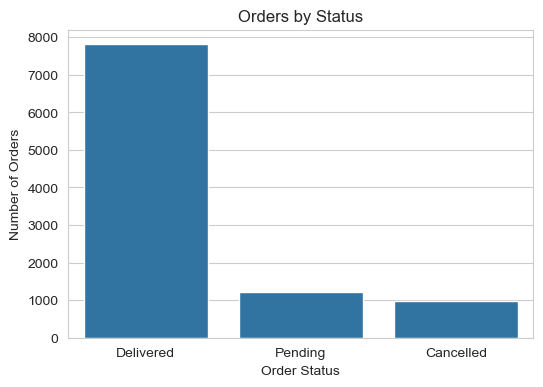

In [33]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="OrderStatus", order=["Delivered", "Pending", "Cancelled"])
plt.title("Orders by Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.show()

# 1. Sales Over Time

Business Question 1: How much revenue does ShopEase generate, and how does it change month by month?

We'll look at monthly revenue, orders and average order value, then check whether certain days of the week sell more. Time analysis shows whether the business is growing, shrinking or steady, and when demand is strongest.

Two reminders:

Revenue means Delivered orders only.
25 orders have no usable order date, so they can't be placed on a timeline and are left out of this section only.

#### Monthly summary table

In [34]:
month_order = ["January", "February", "March", "April", "May", "June"]

dated_orders = df[df["OrderDate"].notnull()]
delivered_dated = dated_orders[dated_orders["OrderStatus"] == "Delivered"]

monthly = pd.DataFrame({
    "Orders": dated_orders.groupby("OrderMonth").size(),
    "Delivered Orders": delivered_dated.groupby("OrderMonth").size(),
    "Revenue": delivered_dated.groupby("OrderMonth")["TotalAmount"].sum(),
    "Avg Order Value": delivered_dated.groupby("OrderMonth")["TotalAmount"].mean().round(2)
})

monthly = monthly.reindex(month_order)
monthly["Revenue Change %"] = (monthly["Revenue"].pct_change() * 100).round(1)
monthly

,Orders,Delivered Orders,Revenue,Avg Order Value,Revenue Change %
OrderMonth,,,,,
January,1735,1370,4751973.00,3468.59,NaN
February,1579,1233,4189496.75,3397.81,-11.8
March,1752,1372,4431687.25,3230.09,5.8
April,1651,1261,4004161.50,3175.39,-9.6
May,1716,1325,4382397.50,3307.47,9.4
June,1542,1230,4280271.00,3479.90,-2.3


Interpretation:

1. Average monthly revenue is about 4.34 million.
2. January is the best month (4.75 million) and April the lowest (4.00 million), a gap of about 19%.
3. Revenue goes up and down by roughly 2% to 12% from month to month, with no steady rise or fall.
4. Orders follow the same pattern: March (1,752) is highest and June (1,542) lowest.
5. Average order value stays between about 3,175 and 3,480, so the changes in revenue come mainly from how many orders were placed and not from larger baskets.

### Line chart of monthly revenue

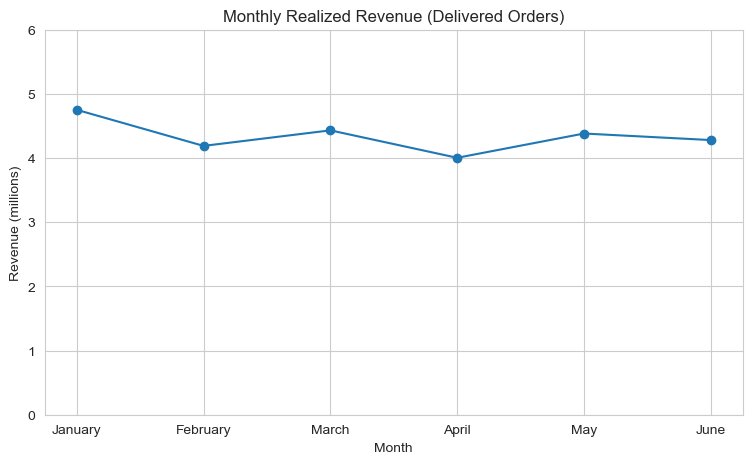

In [35]:
plt.figure(figsize=(9, 5))
plt.plot(monthly.index, monthly["Revenue"] / 1_000_000, marker="o")
plt.title("Monthly Realized Revenue (Delivered Orders)")
plt.xlabel("Month")
plt.ylabel("Revenue (millions)")
plt.ylim(0, 6)
plt.grid(True)
plt.show()

February has only 28 days, and your data ends on 29 June, so June is one day short. That makes those two months look slightly smaller than they really are.

### Orders and revenue by day of the week

              Orders     Revenue
OrderWeekday                    
Monday          1443  3899215.25
Tuesday         1461  3704907.00
Wednesday       1380  3457788.50
Thursday        1401  3674052.75
Friday          1417  3528207.50
Saturday        1419  3670663.50
Sunday          1454  4105152.50


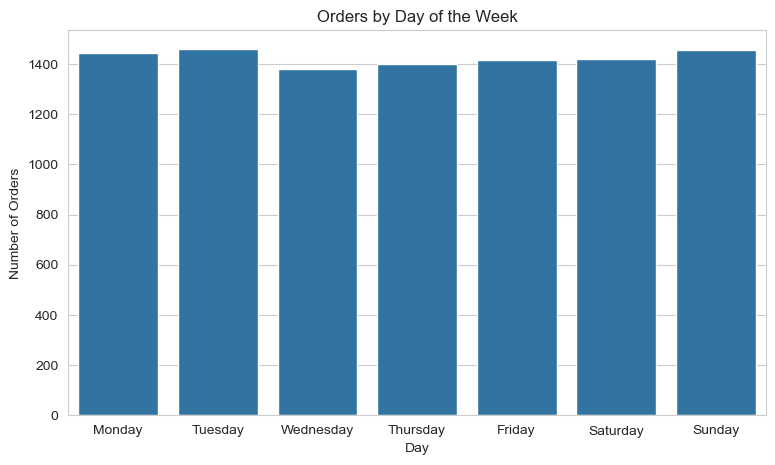

In [36]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

weekday_summary = pd.DataFrame({
    "Orders": dated_orders.groupby("OrderWeekday").size(),
    "Revenue": delivered_dated.groupby("OrderWeekday")["TotalAmount"].sum()
}).reindex(weekday_order)

print(weekday_summary)

plt.figure(figsize=(9, 5))
sns.barplot(x=weekday_summary.index, y=weekday_summary["Orders"])
plt.title("Orders by Day of the Week")
plt.xlabel("Day")
plt.ylabel("Number of Orders")
plt.show()

Sunday has the highest revenue (4.11 million) and Wednesday the lowest (3.46 million), a gap of about 19%, even though their order counts differ by only about 5%. That means Sunday's orders happened to be larger in value. This can easily come from a few big orders such as Laptops, so treat it as a weak signal and not a firm conclusion.

##### ShopEase earns about 4.34 million per month in realized revenue. Revenue fluctuates between 4.00 million (April) and 4.75 million (January) with no clear upward or downward trend, and orders are spread evenly across the days of the week. Cancellations stay at about 9% to 11% of orders in every month, so the cancellation problem is steady and not caused by one bad month.

# 2. Categories and Products 

Business Question 2: Which categories and products contribute most to revenue and orders?

This shows where the money comes from and how dependent the business is on a few items. As before, revenue means Delivered orders only

### Category summary

In [37]:
delivered = df[df["OrderStatus"] == "Delivered"]
realized_revenue = delivered["TotalAmount"].sum()

category_summary = pd.DataFrame({
    "Orders": df.groupby("Category").size(),
    "Delivered Orders": delivered.groupby("Category").size(),
    "Revenue": delivered.groupby("Category")["TotalAmount"].sum(),
    "Avg Order Value": delivered.groupby("Category")["TotalAmount"].mean().round(2)
})

category_summary["Revenue Share %"] = (category_summary["Revenue"] / realized_revenue * 100).round(1)
category_summary["Order Share %"] = (category_summary["Delivered Orders"] / len(delivered) * 100).round(1)
category_summary = category_summary.sort_values("Revenue", ascending=False)
category_summary

,Orders,Delivered Orders,Revenue,Avg Order Value,Revenue Share %,Order Share %
Category,,,,,,
Electronics,1986,1544,13573966.00,8791.43,52.0,19.8
Home,2032,1572,3781075.00,2405.26,14.5,20.1
Sports,2018,1584,3577101.00,2258.27,13.7,20.3
Fashion,2000,1583,2942360.25,1858.72,11.3,20.3
Beauty,1964,1527,2248495.25,1472.49,8.6,19.6


##### Interpretation:

1. Order counts are almost equal across the five categories (each has about 20% of delivered orders).
2. Revenue is not equal at all.Electronics brings in 52% of revenue from only 19.8% of orders.
3. The reason is price: the average Electronics order is worth about 8,791, compared with 1,472 to 2,405 in the other categories.

### Chart of category revenue and orders

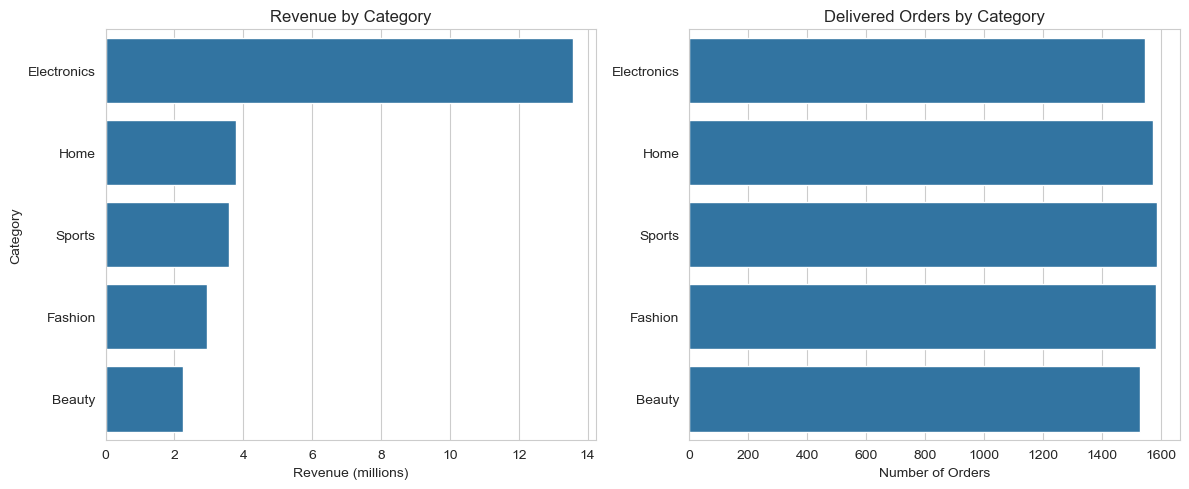

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x=category_summary["Revenue"] / 1_000_000, y=category_summary.index, orient="h", ax=axes[0])
axes[0].set_title("Revenue by Category")
axes[0].set_xlabel("Revenue (millions)")
axes[0].set_ylabel("Category")

sns.barplot(x=category_summary["Delivered Orders"], y=category_summary.index, orient="h", ax=axes[1])
axes[1].set_title("Delivered Orders by Category")
axes[1].set_xlabel("Number of Orders")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### Product summary

In [39]:
known_delivered = delivered[delivered["Product"] != "Unknown"]

product_summary = pd.DataFrame({
    "Category": known_delivered.groupby("Product")["Category"].first(),
    "Delivered Orders": known_delivered.groupby("Product").size(),
    "Units Sold": known_delivered.groupby("Product")["Quantity"].sum(),
    "Revenue": known_delivered.groupby("Product")["TotalAmount"].sum()
})

product_summary["Revenue Share %"] = (product_summary["Revenue"] / realized_revenue * 100).round(1)
product_summary = product_summary.sort_values("Revenue", ascending=False)
product_summary["Cumulative Share %"] = product_summary["Revenue Share %"].cumsum().round(1)
product_summary

,Category,Delivered Orders,Units Sold,Revenue,Revenue Share %,Cumulative Share %
Product,,,,,,
Laptop,Electronics,337,657,11059101.00,42.3,42.3
Chair,Home,300,570,1327750.00,5.1,47.4
Smart Watch,Electronics,315,606,1248671.00,4.8,52.2
Coffee Maker,Home,339,682,1146411.00,4.4,56.6
Running Shoes,Sports,331,670,1127942.00,4.3,60.9
Shoes,Fashion,344,700,971645.00,3.7,64.6
Tennis Racket,Sports,319,646,965832.00,3.7,68.3
Dumbbells,Sports,304,589,774707.00,3.0,71.3
Jacket,Fashion,320,647,727824.00,2.8,74.1


Why exclude “Unknown” here: 15 delivered orders (57,452.50, about 0.2% of revenue) have no product name. They’re left out of this product table only, and they are still counted in the category totals, because their category is known

##### The three lowest products are Face Cream (246,026.25, 0.9%), Lamp (158,103.00, 0.6%) and Shampoo (143,427.00, 0.5%). The 25 named products add up to about 99.8% of revenue.

##### Interpretation:

1. One product, the Laptop, earns 42.3% of all realized revenue, from only 337 delivered orders (about 4.3% of orders).
2. The top 5 products give 60.9% of revenue, and the top 10 give 76.8%.
3. The bottom products each contribute less than 1%.

### Chart of the top 10 products

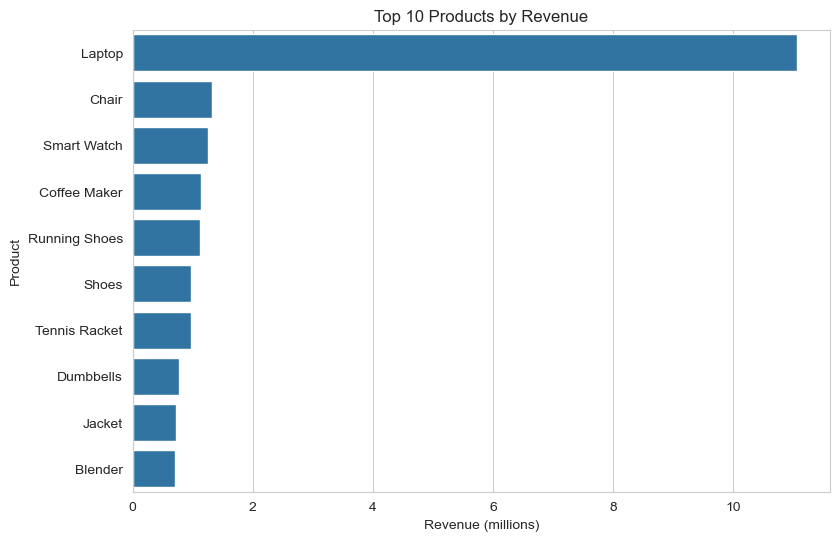

In [40]:
top10 = product_summary.head(10)

plt.figure(figsize=(9, 6))
sns.barplot(x=top10["Revenue"] / 1_000_000, y=top10.index, orient="h")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (millions)")
plt.ylabel("Product")
plt.show()

### Popular is not the same as profitable

In [41]:
product_summary["Delivered Orders"].sort_values(ascending=False).head(5)

Product
Shoes           344
Yoga Mat        342
Coffee Maker    339
Laptop          337
Bedsheet        333
Name: Delivered Orders, dtype: int64

##### Interpretation: 
By number of orders, products are nearly tied (all about 280 to 345). Yoga Mat is the second most ordered product, but it earns only 363,159 in revenue, while the Laptop ranks fourth in orders and first by a huge margin in revenue. Revenue differences come almost entirely from price, not from how popular each product is.

##### Orders are spread evenly across the five categories and 25 products, but revenue is highly uneven. Electronics earns 52% of realized revenue from only about 20% of orders, and a single product, the Laptop, earns 42.3%. The top 5 products produce 61% of revenue. ShopEase’s revenue therefore depends heavily on a small number of high-priced items.

# 3. Order Status, Cities and Payment Methods

Business Question 3: What percentage of orders is delivered, pending or cancelled, and does it differ by city, category or payment method?

Business Question 4: Which cities and payment methods are used most?

If cancellations clustered in one city or payment method, that would point to a specific problem to fix. If they’re spread evenly, the cause is more general.

### Order status percentages by city, category and payment method

In [42]:
for column in ["City", "Category", "PaymentMethod"]:
    print("-----", column, "-----")
    print((pd.crosstab(df[column], df["OrderStatus"], normalize="index") * 100).round(2))
    print()

----- City -----
OrderStatus  Cancelled  Delivered  Pending
City                                      
Alexandria       10.02      78.80    11.18
Aswan            10.75      79.38     9.88
Cairo             8.99      79.10    11.91
Giza             10.24      76.25    13.51
Mansoura         10.08      76.69    13.23
Tanta            10.79      77.58    11.64

----- Category -----
OrderStatus  Cancelled  Delivered  Pending
Category                                  
Beauty            9.57      77.75    12.68
Electronics       9.82      77.74    12.44
Fashion           8.60      79.15    12.25
Home             10.78      77.36    11.86
Sports           10.16      78.49    11.35

----- PaymentMethod -----
OrderStatus    Cancelled  Delivered  Pending
PaymentMethod                               
Bank Transfer      10.06      78.40    11.54
Cash                8.81      78.96    12.23
Mastercard          9.30      77.56    13.14
Unknown             4.08      63.27    32.65
Visa               

### Interpretation:

1. Almost every group sits near the overall split of 78% delivered, 12% pending, 10% cancelled.
2. Cancellation rates range from about 8.6% to 10.8%, so no city, category or payment method stands out.
3. One exception: orders with an Unknown payment method are pending 32.7% of the time, compared with about 12% elsewhere. That group has only 49 orders (16 pending), so treat it as a small-sample observation. A plausible reading is that an order with no payment method recorded often hasn’t been completed yet, but the data can’t prove that.

### Chart of cancellation rate by city

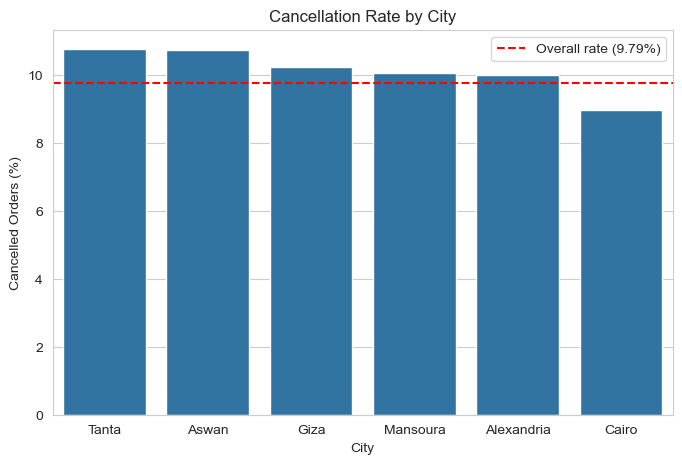

In [43]:
cancel_by_city = (df["OrderStatus"] == "Cancelled").groupby(df["City"]).mean() * 100
cancel_by_city = cancel_by_city.sort_values(ascending=False)
overall_rate = (df["OrderStatus"] == "Cancelled").mean() * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=cancel_by_city.index, y=cancel_by_city.values)
plt.axhline(overall_rate, color="red", linestyle="--", label=f"Overall rate ({overall_rate:.2f}%)")
plt.title("Cancellation Rate by City")
plt.xlabel("City")
plt.ylabel("Cancelled Orders (%)")
plt.legend()
plt.show()

Cancellations are not a problem of one city. The gaps are about one percentage point.

### Are these differences real or just chance?

Small differences can appear by chance, even when nothing is going on. The chi-square test checks this. It gives a p-value:

1. p below 0.05: the difference is probably real.
2. p above 0.05: the difference could easily be chance.

In [44]:
from scipy import stats

def test_status_difference(column_name, data):
    table = pd.crosstab(data[column_name], data["OrderStatus"])
    chi2, p_value, dof, expected = stats.chi2_contingency(table)
    print(column_name, "| p-value:", round(p_value, 4))

test_status_difference("City", df)
test_status_difference("Category", df)
test_status_difference("PaymentMethod", df[df["PaymentMethod"] != "Unknown"])

City | p-value: 0.1463
Category | p-value: 0.4709
PaymentMethod | p-value: 0.3612


#### Interpretation: 
all three p-values are above 0.05. The differences in order status between cities, categories and payment methods are small enough to be chance. If you include the Unknown payment group, the payment p-value drops to 0.0013, which shows that group is the only thing making payment look different.

### Where does the lost revenue come from?

In [45]:
cancelled = df[df["OrderStatus"] == "Cancelled"]
cancelled_value = cancelled["TotalAmount"].sum()

cancelled_by_category = cancelled.groupby("Category")["TotalAmount"].agg(["count", "sum"]).round(0)
cancelled_by_category["Share of cancelled value %"] = (cancelled_by_category["sum"] / cancelled_value * 100).round(1)
print(cancelled_by_category.sort_values("sum", ascending=False))

laptop_orders = df[df["Product"] == "Laptop"]
laptop_cancelled = laptop_orders[laptop_orders["OrderStatus"] == "Cancelled"]

print("Laptop cancellation rate:", round(len(laptop_cancelled) / len(laptop_orders) * 100, 2), "%")
print("Laptop share of cancelled value:", round(laptop_cancelled["TotalAmount"].sum() / cancelled_value * 100, 1), "%")

             count        sum  Share of cancelled value %
Category                                                 
Electronics    195  1606990.0                        51.6
Home           219   484558.0                        15.6
Sports         205   458779.0                        14.7
Fashion        172   304360.0                         9.8
Beauty         188   259474.0                         8.3
Laptop cancellation rate: 8.39 %
Laptop share of cancelled value: 42.0 %


### Interpretation:
Home has the most cancelled orders (219), but Electronics accounts for 51.6% of the cancelled money. The Laptop is cancelled less often than average (8.39% against 9.79%), yet it makes up 42% of the lost value, simply because each Laptop order is worth so much. So cancellations lose money mainly through high-priced orders, not because any product is cancelled more.

### Which cities and payment methods are used most?

In [46]:
delivered = df[df["OrderStatus"] == "Delivered"]
realized_revenue = delivered["TotalAmount"].sum()

city_summary = pd.DataFrame({
    "Orders": df.groupby("City").size(),
    "Revenue": delivered.groupby("City")["TotalAmount"].sum(),
    "Avg Order Value": delivered.groupby("City")["TotalAmount"].mean().round(2)
})
city_summary["Order Share %"] = (city_summary["Orders"] / len(df) * 100).round(1)
city_summary["Revenue Share %"] = (city_summary["Revenue"] / realized_revenue * 100).round(1)
city_summary = city_summary.sort_values("Orders", ascending=False)
print(city_summary)
print()

payment_summary = pd.DataFrame({
    "Orders": df.groupby("PaymentMethod").size(),
    "Revenue": delivered.groupby("PaymentMethod")["TotalAmount"].sum(),
    "Avg Order Value": delivered.groupby("PaymentMethod")["TotalAmount"].mean().round(2)
})
payment_summary["Order Share %"] = (payment_summary["Orders"] / len(df) * 100).round(1)
payment_summary["Revenue Share %"] = (payment_summary["Revenue"] / realized_revenue * 100).round(1)
payment_summary = payment_summary.sort_values("Orders", ascending=False)
print(payment_summary)

            Orders     Revenue  Avg Order Value  Order Share %  \
City                                                             
Cairo         3760  9868640.25          3318.31           37.6   
Giza          2021  5484095.75          3558.79           20.2   
Alexandria    1736  4710702.00          3443.50           17.4   
Mansoura      1081  2804632.00          3383.15           10.8   
Tanta          825  1866138.00          2915.84            8.2   
Aswan          577  1388789.50          3032.29            5.8   

            Revenue Share %  
City                         
Cairo                  37.8  
Giza                   21.0  
Alexandria             18.0  
Mansoura               10.7  
Tanta                   7.1  
Aswan                   5.3  

               Orders     Revenue  Avg Order Value  Order Share %  \
PaymentMethod                                                       
Cash             2044  5590995.50          3464.06           20.4   
Visa             2024  

#### Interpretation:

* Cairo alone supplies 37.6% of orders and 37.8% of revenue. Cairo, Giza and Alexandria together account for 75.2% of orders.
* Tanta and Aswan have a larger share of orders than of revenue, because their average order value is lower.
* Payment methods are split almost evenly, each with about 20% of orders. Cash is the most used, but only by a small margin.
* Bank Transfer and Mastercard have lower average order values (about 3,040 and 3,090) than Wallet, Visa and Cash (about 3,460 to 3,540). This is only a weak signal, since a few large Laptop orders can easily shift an average.

### Charts for cities and payment methods

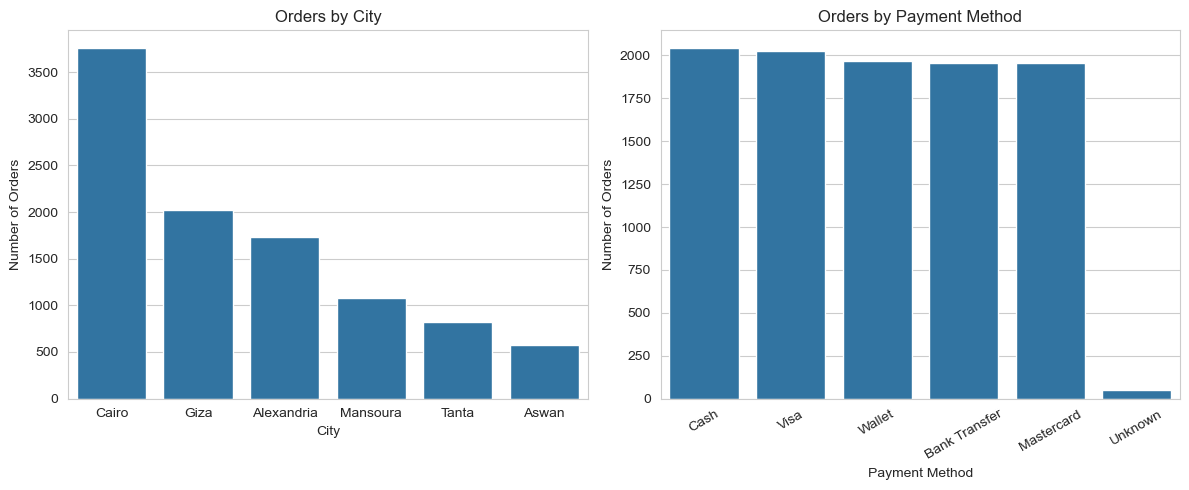

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x=city_summary.index, y=city_summary["Orders"], ax=axes[0])
axes[0].set_title("Orders by City")
axes[0].set_xlabel("City")
axes[0].set_ylabel("Number of Orders")

sns.barplot(x=payment_summary.index, y=payment_summary["Orders"], ax=axes[1])
axes[1].set_title("Orders by Payment Method")
axes[1].set_xlabel("Payment Method")
axes[1].set_ylabel("Number of Orders")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

##### About 78% of orders are delivered, 12% are pending and 10% cancelled, and this split is similar across every city, category and payment method. Statistical tests (p-values 0.15, 0.47 and 0.36) show the differences are small enough to be chance. The one exception is the small group of 49 orders with no recorded payment method, which are far more often pending (32.7%). Cancellations cost the most money in Electronics (51.6% of lost value) because of high-priced orders like Laptops.

##### Cairo is the biggest market with 37.6% of orders, and Cairo, Giza and Alexandria together provide 75.2%. Payment methods are used almost equally, about 20% each, with Cash slightly ahead.

# Discounts, Delivery Time and Ratings

Question 5: Do discounts change the quantity ordered, and how much revenue do they give up?

Question 6: How long does delivery take, and does it vary by city?

Question 7: Are customer ratings related to delivery time or discount?

These test common business beliefs, such as “discounts boost sales” and “slow delivery hurts ratings”

### Discounts

Orders with a discount: 65.1%
                 count  mean
DiscountPercent             
0.0               3490  1.98
5.0               1954  1.97
10.0              2534  1.99
15.0              1529  1.96
20.0               492  1.93
Correlation between discount and quantity: -0.007


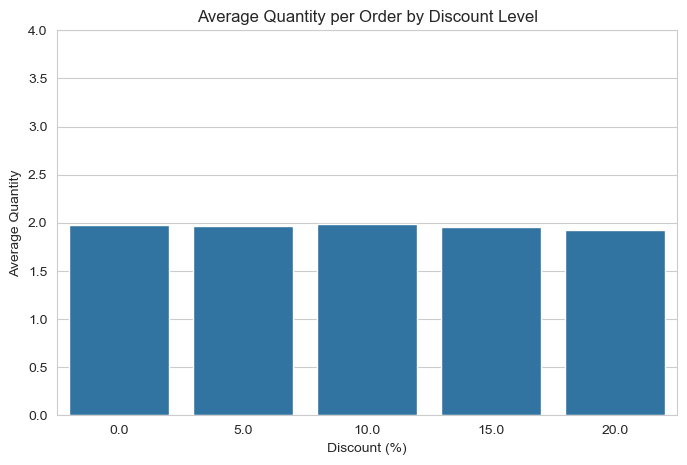

In [48]:
discounted_share = (df["Discount"] > 0).mean() * 100
print(f"Orders with a discount: {discounted_share:.1f}%")

discount_quantity = df.groupby("DiscountPercent")["Quantity"].agg(["count", "mean"]).round(2)
print(discount_quantity)

print("Correlation between discount and quantity:",
      round(df["DiscountPercent"].corr(df["Quantity"].astype(float)), 3))

plt.figure(figsize=(8, 5))
sns.barplot(x=discount_quantity.index, y=discount_quantity["mean"])
plt.title("Average Quantity per Order by Discount Level")
plt.xlabel("Discount (%)")
plt.ylabel("Average Quantity")
plt.ylim(0, 4)
plt.show()

A limit to remember: we only see customers who ordered. The data can’t tell us whether discounts bring in more orders, only that they don’t make customers buy more units per order.

### How much revenue do discounts give up?

In [49]:
delivered = df[df["OrderStatus"] == "Delivered"].copy()
delivered["GrossValue"] = delivered["Quantity"] * delivered["UnitPrice"]
delivered["DiscountAmount"] = delivered["GrossValue"] * delivered["Discount"]

print(f"Value before discount: {delivered['GrossValue'].sum():,.2f}")
print(f"Discount given: {delivered['DiscountAmount'].sum():,.2f}")
print(f"Discount as % of value before discount: {delivered['DiscountAmount'].sum() / delivered['GrossValue'].sum() * 100:.2f}%")

discount_summary = delivered.groupby("DiscountPercent").agg(
    Orders=("OrderID", "size"),
    Revenue=("TotalAmount", "sum"),
    DiscountGiven=("DiscountAmount", "sum")
).round(0)
discount_summary

Value before discount: 27,940,650.00
Discount given: 1,855,047.50
Discount as % of value before discount: 6.64%


,Orders,Revenue,DiscountGiven
DiscountPercent,,,
0.0,2725,10259197.0,0.0
5.0,1524,4737248.0,249175.0
10.0,1982,6479384.0,718330.0
15.0,1199,3722856.0,656482.0
20.0,380,924312.0,231060.0


#### Interpretation:

* Delivered orders gave away about 1.86 million, or 6.6% of their pre-discount value.
* The 10% and 15% discounts account for about 74% of the money given away, because they’re the most common levels with substantial amounts.
* These figures are recalculated from Quantity × UnitPrice × Discount, so they can differ slightly from the recorded TotalAmount (about 1% of rows don’t match exactly).

* The average order value by discount level falls from about 3,684 (no discount) to 2,461 (20% discount). Since TotalAmount is after discount, part of that gap is simply the discount itself. Don’t read it as “discounts reduce order size”.

##### About 65% of orders carry a discount, averaging around 10%. In this dataset discounts do not increase the quantity ordered (correlation -0.007), and they gave up roughly 1.86 million (6.6%) of delivered order value. The data shows the cost of discounts but no evidence that they raise units per order. It can’t show whether they win extra orders.

### Delivery time by city

### Does delivery time differ by city?

            count  mean  median
City                           
Tanta         629  3.49     3.0
Giza         1525  3.52     3.0
Mansoura      823  3.53     3.0
Cairo        2943  3.55     3.0
Alexandria   1356  3.59     3.0
Aswan         455  3.60     4.0
Delivered within 3 days: 52.7 %
Took 6 or 7 days: 11.9 %
p-value (difference between cities): 0.4655


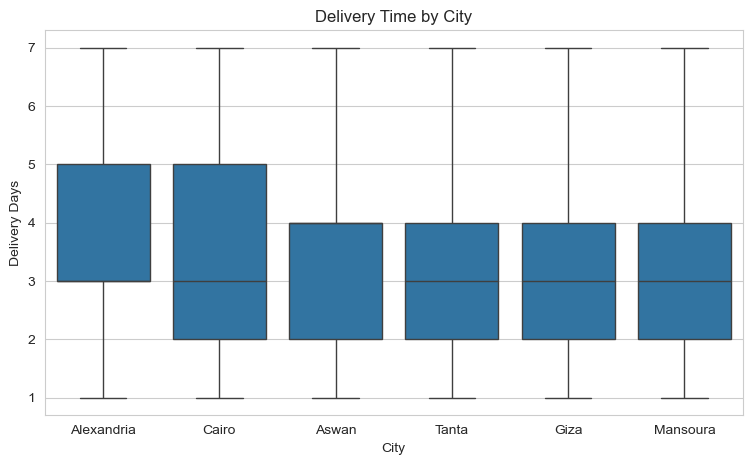

In [50]:
delivery_by_city = df.groupby("City")["DeliveryDays"].agg(["count", "mean", "median"]).round(2).sort_values("mean")
print(delivery_by_city)

delivery_days = df["DeliveryDays"].dropna()
print("Delivered within 3 days:", round((delivery_days <= 3).mean() * 100, 1), "%")
print("Took 6 or 7 days:", round((delivery_days >= 6).mean() * 100, 1), "%")

groups = [group["DeliveryDays"].dropna() for city, group in df.groupby("City")]
print("p-value (difference between cities):", round(stats.kruskal(*groups)[1], 4))

plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="City", y="DeliveryDays")
plt.title("Delivery Time by City")
plt.xlabel("City")
plt.ylabel("Delivery Days")
plt.show()

##### Delivery takes about 3.5 days on average (1 to 7 days). Just over half of deliveries (52.7%) arrive within 3 days, and about 12% take 6 or 7 days. Delivery time does not differ meaningfully between cities (p = 0.47). Categories are the same, with averages from 3.48 to 3.59 days.

### Ratings -How do customers rate?

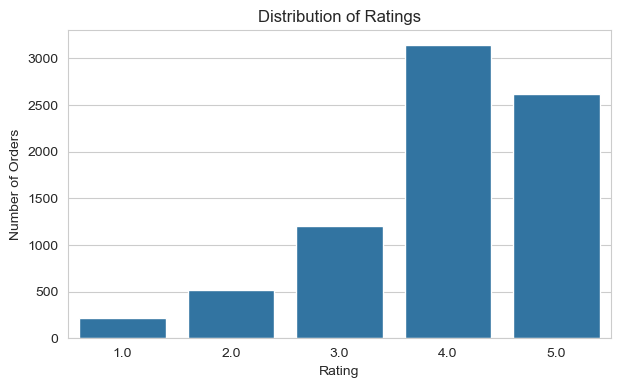

Ratings given: 7699
Average rating: 3.96
Rated 4 or 5: 74.8 %
Rated 1 or 2: 9.6 %


In [51]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Rating", order=[1.0, 2.0, 3.0, 4.0, 5.0])
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Orders")
plt.show()

rated = df["Rating"].dropna()
print("Ratings given:", len(rated))
print("Average rating:", round(rated.mean(), 2))
print("Rated 4 or 5:", round((rated >= 4).mean() * 100, 1), "%")
print("Rated 1 or 2:", round((rated <= 2).mean() * 100, 1), "%")

### Do delivery time or discount affect ratings?

DeliveryDays
1.0    3.90
2.0    3.94
3.0    3.99
4.0    3.93
5.0    4.06
6.0    3.93
7.0    3.95
Name: Rating, dtype: float64


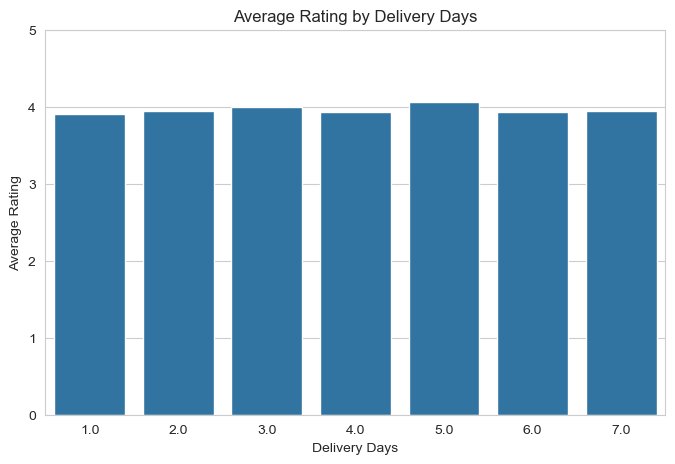

DiscountPercent
0.0     3.97
5.0     3.92
10.0    3.97
15.0    3.98
20.0    3.98
Name: Rating, dtype: float64
                 DiscountPercent  Quantity  DeliveryDays  Rating
DiscountPercent            1.000    -0.007        -0.002   0.005
Quantity                  -0.007     1.000        -0.008   0.011
DeliveryDays              -0.002    -0.008         1.000   0.015
Rating                     0.005     0.011         0.015   1.000


In [52]:
avg_rating_by_days = df.groupby("DeliveryDays")["Rating"].mean().round(2)
print(avg_rating_by_days)

plt.figure(figsize=(8, 5))
sns.barplot(x=avg_rating_by_days.index, y=avg_rating_by_days.values)
plt.title("Average Rating by Delivery Days")
plt.xlabel("Delivery Days")
plt.ylabel("Average Rating")
plt.ylim(0, 5)
plt.show()

avg_rating_by_discount = df.groupby("DiscountPercent")["Rating"].mean().round(2)
print(avg_rating_by_discount)

print(df[["DiscountPercent", "Quantity", "DeliveryDays", "Rating"]].astype(float).corr().round(3))

The average rating is slightly higher at 5 days (4.06), but it doesn’t continue to rise or fall in a consistent direction, and the gap is under 0.2 stars. It looks like random variation, not a pattern. Whatever drives ratings in this dataset is not one of the variables we have.

##### The average rating is 3.96 out of 5, and 74.8% of rated orders score 4 or 5. Ratings are not related to delivery time or discount: all correlations are close to zero (below 0.02), and average ratings stay between about 3.9 and 4.1 across delivery times and discount levels.

# Customers

Question 8: What do customer age and gender tell us about buying behavior?

### Gender

In [55]:
delivered = df[df["OrderStatus"] == "Delivered"]
realized_revenue = delivered["TotalAmount"].sum()

gender_summary = pd.DataFrame({
    "Orders": df.groupby("Gender").size(),
    "Revenue": delivered.groupby("Gender")["TotalAmount"].sum(),
    "Avg Order Value": delivered.groupby("Gender")["TotalAmount"].mean().round(2),
    "Median Order Value": delivered.groupby("Gender")["TotalAmount"].median()
})
gender_summary["Order Share %"] = (gender_summary["Orders"] / len(df) * 100).round(1)
gender_summary["Revenue Share %"] = (gender_summary["Revenue"] / realized_revenue * 100).round(1)
print(gender_summary)

male_values = delivered[delivered["Gender"] == "Male"]["TotalAmount"]
female_values = delivered[delivered["Gender"] == "Female"]["TotalAmount"]
print("p-value (Male vs Female order value):", round(stats.mannwhitneyu(male_values, female_values)[1], 4))

        Orders     Revenue  Avg Order Value  Median Order Value  \
Gender                                                            
Female    4991  12961267.0          3346.57              1600.0   
Male      5009  13161730.5          3343.09              1615.0   

        Order Share %  Revenue Share %  
Gender                                  
Female           49.9             49.6  
Male             50.1             50.4  
p-value (Male vs Female order value): 0.9001


#### Interpretation: 

The genders are almost perfectly balanced in orders, revenue and average order value (3,346.57 against 3,343.09). A p-value of 0.90 means there’s no difference worth noting

### Age

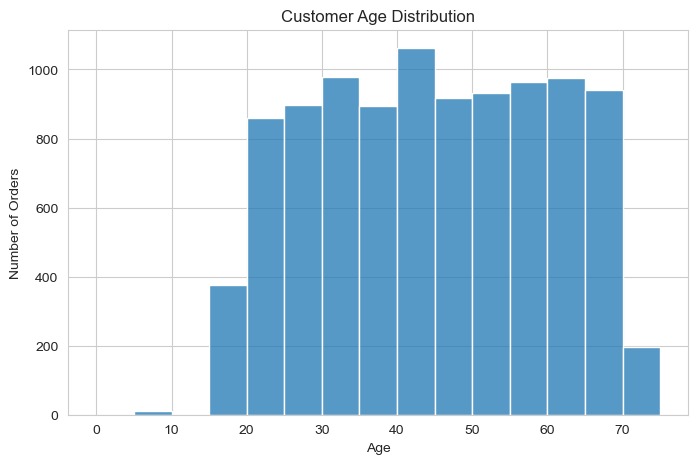

,Orders,Revenue,Avg Order Value,Median Order Value,Order Share %,Revenue Share %
AgeGroup,,,,,,
Under 25,1246,3590064.25,3685.90,1500.0,12.5,13.7
25-34,1873,4827022.50,3283.69,1620.0,18.7,18.5
35-44,1957,4603713.25,3048.82,1530.0,19.6,17.6
45-54,1849,4983077.00,3417.75,1600.0,18.5,19.1
55-64,1939,5347067.00,3536.42,1615.0,19.4,20.5
65+,1136,2772053.50,3128.73,1620.0,11.4,10.6


In [56]:
plt.figure(figsize=(8, 5))
sns.histplot(df["CustomerAge"], bins=range(0, 80, 5))
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Orders")
plt.show()

age_order = ["Under 25", "25-34", "35-44", "45-54", "55-64", "65+"]

age_summary = pd.DataFrame({
    "Orders": df.groupby("AgeGroup", observed=True).size(),
    "Revenue": delivered.groupby("AgeGroup", observed=True)["TotalAmount"].sum(),
    "Avg Order Value": delivered.groupby("AgeGroup", observed=True)["TotalAmount"].mean().round(2),
    "Median Order Value": delivered.groupby("AgeGroup", observed=True)["TotalAmount"].median()
}).reindex(age_order)

age_summary["Order Share %"] = (age_summary["Orders"] / len(df) * 100).round(1)
age_summary["Revenue Share %"] = (age_summary["Revenue"] / realized_revenue * 100).round(1)
age_summary

Interpretation:

* Order and revenue shares follow each other closely. The smaller shares for Under 25 and 65+ come from narrower age bands (the youngest adult is 18 and the oldest customer is 70).
* Under 25 has the highest average order value (3,686) but the lowest median (1,500). The mean is far above the median, which is the usual sign that a few large orders pull the average up.

### Do gender or age change what people buy?

In [57]:
print("Gender vs Category p-value:", round(stats.chi2_contingency(pd.crosstab(df["Gender"], df["Category"]))[1], 4))
print("Age group vs Category p-value:", round(stats.chi2_contingency(pd.crosstab(df["AgeGroup"], df["Category"]))[1], 4))

age_groups = [group["TotalAmount"] for name, group in delivered.groupby("AgeGroup", observed=True)]
print("Age group vs order value p-value:", round(stats.kruskal(*age_groups)[1], 4))

Gender vs Category p-value: 0.9299
Age group vs Category p-value: 0.8174
Age group vs order value p-value: 0.5219


##### Interpretation: 
all three p-values are far above 0.05, so there’s no evidence that gender or age changes which category people buy from or how much they spend. The correlation between age and order value is also essentially zero (-0.007).

### An important check on CustomerID

In [59]:
with_id = df[df["CustomerID"].notnull()]

per_customer = with_id.groupby("CustomerID").agg(
    Ages=("CustomerAge", "nunique"),
    Genders=("Gender", "nunique"),
    Cities=("City", "nunique")
)

print("Customer IDs:", len(per_customer))
print("IDs with more than one age:", (per_customer["Ages"] > 1).sum())
print("IDs with more than one gender:", (per_customer["Genders"] > 1).sum())
print("IDs with more than one city:", (per_customer["Cities"] > 1).sum())

Customer IDs: 1988
IDs with more than one age: 1920
IDs with more than one gender: 1693
IDs with more than one city: 1845


##### Interpretation: 
About 97% of customer IDs have several different ages, 85% have both genders, and 93% appear in more than one city. A real person doesn’t change gender or age between orders. So in this dataset a CustomerID does not identify one consistent person. It looks like a property of how the practice data was generated, though the data can’t tell us why.

### Orders per customer ID

count    1988.00
mean        5.02
std         2.18
min         1.00
25%         3.00
50%         5.00
75%         6.00
max        14.00
dtype: float64
IDs with only one order: 64
1       64
2-3    449
4-5    711
6-7    516
8-9    181
10+     67
Name: count, dtype: int64


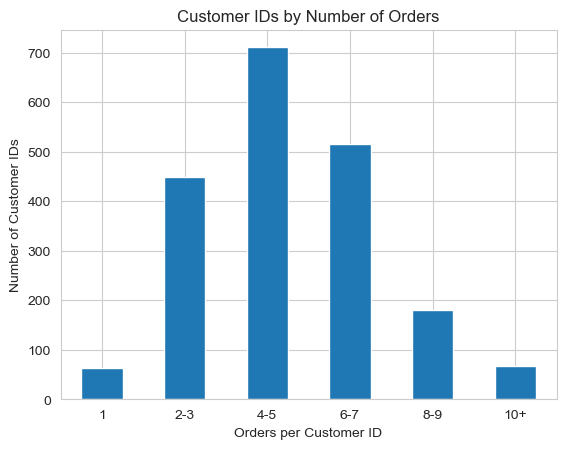

In [60]:
orders_per_customer = with_id.groupby("CustomerID").size()
print(orders_per_customer.describe().round(2))
print("IDs with only one order:", (orders_per_customer == 1).sum())

order_bands = pd.cut(orders_per_customer, [0, 1, 3, 5, 7, 9, 20],
                     labels=["1", "2-3", "4-5", "6-7", "8-9", "10+"])
print(order_bands.value_counts().sort_index())

order_bands.value_counts().sort_index().plot(kind="bar")
plt.title("Customer IDs by Number of Orders")
plt.xlabel("Orders per Customer ID")
plt.ylabel("Number of Customer IDs")
plt.xticks(rotation=0)
plt.show()

##### Customers are split evenly by gender (49.9% female, 50.1% male) and spread across ages 18 to 70 (average 44). Neither gender nor age group changes which category people buy (p = 0.93 and 0.82) or how much they spend (p = 0.90 and 0.52). Customer IDs average about 5 orders each, but each ID shows different ages, genders and cities, so repeat-buying and loyalty conclusions can’t be drawn reliably from this dataset.